In [3]:
from sklearn.datasets import make_regression
import numpy as np

In [2]:
x , y = make_regression(n_samples=10, n_features=1 , n_informative=1 , n_targets=1,noise=80 , random_state=42)

In [4]:
from sklearn.model_selection import train_test_split 
x_train , x_test , y_train , y_test = train_test_split(x,y ,test_size=0.2 , random_state=42)

In [5]:

from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [6]:
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
import matplotlib.pyplot as plt

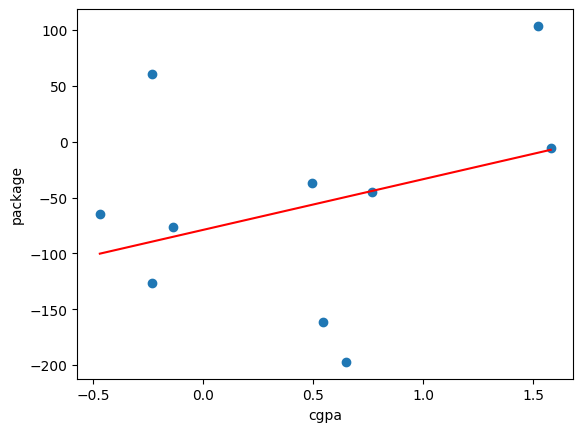

In [16]:
plt.scatter(x,y)
plt.xlabel("cgpa")
plt.ylabel("package")
plt.plot(x_test,lr.predict(x_test),color="red")

### now implementing the GD ( assuming that slope is fixed )

In [ ]:
class SelfGD():

    def __init__(self,lr=0.01,epoches=50):
        # provided the basic learning rate and epoches , in any condition if user does not provide
        # taken these as 0 as i want them to be neutral neither far nor close to the real slope and intercept.
        self.m = 0 
        self.b = 0
        self.lr = lr
        self.epoches = epoches

    def fit (self , X , y ):

        for num in range(self.epoches):

            loss_slope_b = -2 * np.sum(y - self.m*X.ravel() - self.b)
            loss_slope_m = -2 * np.sum((y - self.m*X.ravel() - self.b)*X.ravel())

            self.b = self.b - self.lr * loss_slope_b
            self.m = self.m - self.lr * loss_slope_m
            
    def predict(self , x ):
        
        return self.m*x + self.b

        